In [2]:
from pymongo import MongoClient
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
client = MongoClient("mongodb://localhost:27017/")

db = client["sample_supplies"]

collection = db["sales"]

print(f"total sales:{ collection.count_documents({}):,}")

total sales:5,000


# Q5: How many sales transactions were recorded in each year?

In [5]:
#code for Query 5
from pprint import pprint
pipeline = [
    {
        "$group": {
            "_id" : {"$year" : "$saleDate"},
            "Total Transactions": {"$sum": 1}
        }
    },
    {
        "$sort": {"_id": 1} 
    }
]

years = list(collection.aggregate(pipeline))
pprint(years)

years_df = pd.DataFrame(years)
years_df.rename(columns={"_id": "Year"}, inplace=True)

years_df


[{'Total Transactions': 991, '_id': 2013},
 {'Total Transactions': 941, '_id': 2014},
 {'Total Transactions': 1006, '_id': 2015},
 {'Total Transactions': 1010, '_id': 2016},
 {'Total Transactions': 1052, '_id': 2017}]


,Year,Total Transactions
0,2013,991
1,2014,941
2,2015,1006
3,2016,1010
4,2017,1052


## Code for Visualization

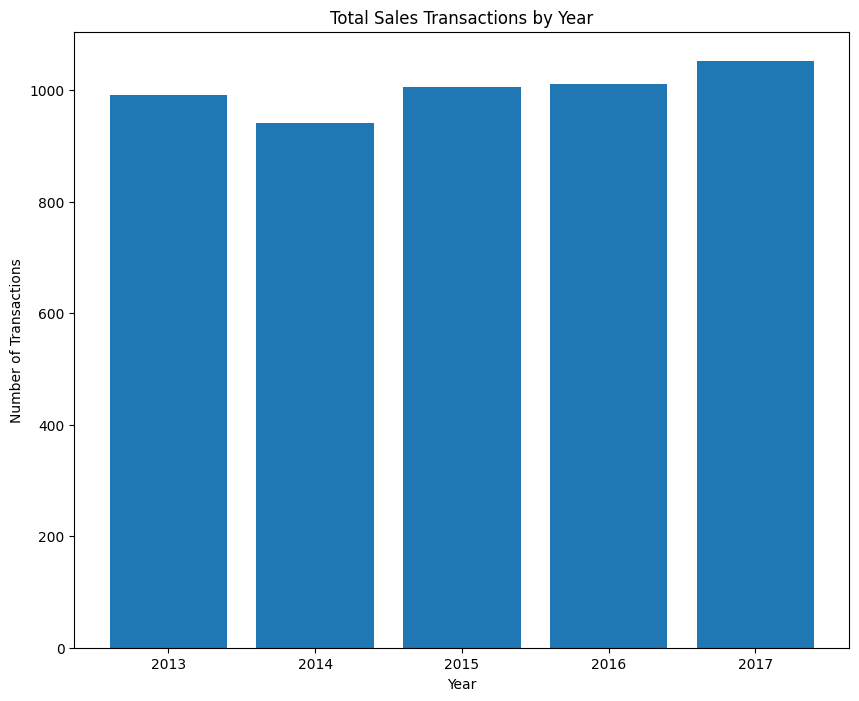

In [6]:
plt.figure(figsize=(10, 8))

plt.bar(years_df["Year"], years_df["Total Transactions"])
plt.title("Total Sales Transactions by Year")
plt.ylabel("Number of Transactions")
plt.xlabel("Year")  

plt.show()